# Phase 6 — Notebook 24: CSE-CIC-IDS2018 baseline & drift premise (G-DRIFT gate)

**Notebook:** `notebooks/08_phase6_cse2018/24_cse2018_baseline.ipynb`
**Pre-registration:** PREREG_cse2018.md + **Addendum A1.3** (chronological day-stream protocol). Clone of notebook 06 for the third dataset.

**What this notebook establishes, in order:**
1. **Family census (A1.2):** exact label→family mapping with flow counts, frozen to `reports/tables/24_family_map.csv`, with an *underpowered* flag (< 1,000 flows) — the composition table already suggests Web and Infiltration are thin.
2. **Baselines:** cold-start frozen RF (trained wed_14_02), balanced, downsampled, oracle — RF config per Appendix B (100 trees, depth 12). A placeholder is provided for the notebook-06 "realistic" baseline (paste its exact definition; do not re-invent it).
3. **Per-day, per-family recall + FPR trajectories** (multiple transitions — no pooling, per A1.3).
4. **G-DRIFT gate (pre-registered):** frozen recall on novel-family flows drops ≥ 0.30 vs its BruteForce recall on the (held-out) training day, on at least half of the *decisive* novel-family days; imbalance controls move recall < 0.01. Per A1.3, Infiltration days are reported but not decisive (documented label noise); the census may add Web days to the non-decisive set if underpowered.

**Split discipline:** every day gets a fixed 70/30 train/eval split (seed 42). All models are evaluated ONLY on the 30% eval split of each day; all training pools draw ONLY from 70% splits. This keeps frozen vs oracle comparable and prevents any train-on-test contact.

**v2 note:** mapping updated to the labels actually present in the improved release (`SSH-BruteForce`, `DoS Hulk`, `DDoS-HOIC`, `Web Attack - *`, `Botnet Ares`, three `Infiltration - *` sub-labels); zero-count Categorical entries (incl. `BENIGN`) filtered; no SlowHTTPTest label exists in this release (record in data card).

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')

import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import joblib

from src.data.loaders import load_dataset, CSE2018_DAY_ORDER
from src.utils.seeding import set_global_seed

set_global_seed(42)
ROOT = Path('/content/drive/MyDrive/phd_thesis')
CKPT = ROOT / 'experiments' / 'checkpoints'
SEED = 42

TRAIN_DAY = 'wed_14_02'            # A1.3 frozen-training day
EVAL_FRAC = 0.30                   # per-day held-out eval split
RF_KW = dict(n_estimators=100, max_depth=12, n_jobs=-1,
             random_state=SEED)    # Appendix B config
ORACLE_PER_DAY = 300_000           # per-day stratified sample for oracle pool
UNDERPOWERED_MIN_FLOWS = 1_000     # family census flag (A1.2)
DRIFT_DROP = 0.30                  # G-DRIFT threshold (A1.3)
IMBALANCE_EPS = 0.01               # imbalance-control threshold (A1.3)

Mounted at /content/drive


## 2. Family census (A1.2) — frozen mapping + power check

Maps every `attack_category` to its family, counts flows per day, flags
underpowered families. This CSV is the frozen mapping the prereg addendum
promised — commit it before notebook 25 runs. Any category the mapping does
not cover triggers an assert (assignment must happen before, not after,
benchmark runs).

In [2]:
FAMILY_MAP = {
    # --- labels observed in the improved release (census-verified) ---
    'FTP-BruteForce': 'BruteForce', 'SSH-BruteForce': 'BruteForce',
    'DoS GoldenEye': 'DoS', 'DoS Slowloris': 'DoS', 'DoS Hulk': 'DoS',
    'DDoS-LOIC-HTTP': 'DDoS', 'DDoS-LOIC-UDP': 'DDoS', 'DDoS-HOIC': 'DDoS',
    'Web Attack - Brute Force': 'Web', 'Web Attack - XSS': 'Web',
    'Web Attack - SQL': 'Web',
    'Infiltration - NMAP Portscan': 'Infiltration',
    'Infiltration - Dropbox Download': 'Infiltration',
    'Infiltration - Communication Victim Attacker': 'Infiltration',
    'Botnet Ares': 'Bot',
    # --- original-release aliases kept harmlessly (match nothing here) ---
    'SSH-Bruteforce': 'BruteForce',
    'DoS attacks-GoldenEye': 'DoS', 'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-SlowHTTPTest': 'DoS', 'DoS attacks-Hulk': 'DoS',
    'DoS SlowHTTPTest': 'DoS',
    'DDoS attacks-LOIC-HTTP': 'DDoS', 'DDOS attack-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',
    'Brute Force -Web': 'Web', 'Brute Force -XSS': 'Web',
    'SQL Injection': 'Web',
    'Infiltration': 'Infiltration', 'Infilteration': 'Infiltration',
    'Bot': 'Bot',
}
# Data-card note: the improved release contains NO SlowHTTPTest label —
# consistent with the corrected-2018 finding that this attack produced no
# genuinely malicious flows. Record in data_card_cse2018.md.

census = []
for day in CSE2018_DAY_ORDER:
    _, y_d, meta_d = load_dataset('cse_cic_ids2018', day=day)
    cats = meta_d.loc[y_d.values == 1, 'attack_category'].astype(str)
    # sanity: attack-labeled rows must never carry the BENIGN category
    assert not (cats.str.upper() == 'BENIGN').any(), f'BENIGN rows with label=1 on {day}!'
    vc = cats.value_counts()
    for cat, cnt in vc.items():
        if cnt == 0 or str(cat).upper() == 'BENIGN':
            continue   # Categorical value_counts() reports zero-count categories
        census.append({'day': day, 'attack_category': str(cat), 'flows': int(cnt)})
census = pd.DataFrame(census)

unmapped = sorted(set(census['attack_category']) - set(FAMILY_MAP))
assert not unmapped, f'Unmapped attack categories — extend FAMILY_MAP first: {unmapped}'

census['family'] = census['attack_category'].map(FAMILY_MAP)
fam_totals = census.groupby('family')['flows'].sum().sort_values(ascending=False)
fam_totals = fam_totals.to_frame('total_flows')
fam_totals['underpowered'] = fam_totals['total_flows'] < UNDERPOWERED_MIN_FLOWS
display(census.pivot_table(index='attack_category', columns='day',
                           values='flows', fill_value=0, aggfunc='sum'))
display(fam_totals)

census.to_csv(ROOT / 'reports' / 'tables' / '24_family_map.csv', index=False)
fam_totals.to_csv(ROOT / 'reports' / 'tables' / '24_family_power.csv')
print('frozen: 24_family_map.csv / 24_family_power.csv')
UNDERPOWERED = set(fam_totals.index[fam_totals['underpowered']])
print('underpowered families:', UNDERPOWERED or 'none')

day,fri_02_03,fri_16_02,fri_23_02,thu_01_03,thu_15_02,thu_22_02,tue_20_02,wed_14_02,wed_21_02,wed_28_02
attack_category,,,,,,,,,,
Botnet Ares,34030,0,0,0,0,0,0,0,0,0
DDoS-HOIC,0,0,0,0,0,0,0,0,233166,0
DDoS-LOIC-HTTP,0,0,0,0,0,0,71679,0,0,0
DDoS-LOIC-UDP,0,0,0,0,0,0,217,0,410,0
DoS GoldenEye,0,0,0,0,7447,0,0,0,0,0
DoS Hulk,0,366005,0,0,0,0,0,0,0,0
DoS Slowloris,0,0,0,0,2986,0,0,0,0,0
FTP-BruteForce,0,21417,0,0,0,0,0,49172,0,0
Infiltration - Communication Victim Attacker,0,0,0,37,0,0,0,0,0,10


,total_flows,underpowered
family,,
DoS,376438,False
DDoS,305472,False
BruteForce,94544,False
Bot,34030,False
Infiltration,20506,False
Web,110,True


frozen: 24_family_map.csv / 24_family_power.csv
underpowered families: {'Web'}


## 3. Per-day 70/30 splits and training pools

Splits are stratified on `attack_category` where possible (falls back to the
binary label if a category has a single flow). Eval indices are persisted so
notebook 25 uses the identical splits.

In [3]:
split_idx = {}
for day in CSE2018_DAY_ORDER:
    X_d, y_d, meta_d = load_dataset('cse_cic_ids2018', day=day)
    strat = meta_d['attack_category'].astype(str)
    # stratify on category when every class has >= 2 members, else on label
    if strat.value_counts().min() < 2:
        strat = y_d
    tr, ev = train_test_split(np.arange(len(y_d)), test_size=EVAL_FRAC,
                              random_state=SEED, stratify=strat)
    split_idx[day] = {'train': tr, 'eval': ev}
    del X_d, y_d, meta_d

np.savez_compressed(ROOT / 'data' / 'processed' / 'phase6_24_splits.npz',
                    **{f'{d}_{k}': v for d, s in split_idx.items()
                       for k, v in s.items()})
print('splits fixed and persisted:',
      {d: len(s['eval']) for d, s in split_idx.items()})

splits fixed and persisted: {'wed_14_02': 450000, 'thu_15_02': 450000, 'fri_16_02': 450000, 'tue_20_02': 450000, 'wed_21_02': 450000, 'thu_22_02': 450001, 'fri_23_02': 450000, 'wed_28_02': 450000, 'thu_01_03': 450001, 'fri_02_03': 450000}


## 4. Train baselines

- **cold_start (frozen):** RF on the 70% of wed_14_02, as-is.
- **cold_start_balanced:** same data, `class_weight='balanced'`.
- **cold_start_downsampled:** benign downsampled to 5x attack count.
- **oracle:** RF on a pooled stratified sample of every day's 70%.
- **realistic (optional):** paste the exact notebook-06 definition below.

Checkpoints go to `experiments/checkpoints/` with the same naming style as
the CICIDS models.

In [4]:
def load_train(day):
    X_d, y_d, meta_d = load_dataset('cse_cic_ids2018', day=day)
    tr = split_idx[day]['train']
    return X_d.iloc[tr], y_d.iloc[tr], meta_d.iloc[tr]

X_tr, y_tr, meta_tr = load_train(TRAIN_DAY)

models = {}

# frozen cold-start
m = RandomForestClassifier(**RF_KW).fit(X_tr, y_tr)
joblib.dump(m, CKPT / 'rf2018_cold_start.joblib'); models['cold_start'] = m

# balanced control
m = RandomForestClassifier(**RF_KW, class_weight='balanced').fit(X_tr, y_tr)
joblib.dump(m, CKPT / 'rf2018_cold_start_balanced.joblib')
models['cold_start_balanced'] = m

# downsampled control (benign : attack = 5 : 1)
atk = np.flatnonzero(y_tr.values == 1)
ben = np.flatnonzero(y_tr.values == 0)
rng = np.random.RandomState(SEED)
ben_ds = rng.choice(ben, size=min(len(ben), 5 * len(atk)), replace=False)
ds = np.concatenate([atk, ben_ds])
m = RandomForestClassifier(**RF_KW).fit(X_tr.iloc[ds], y_tr.iloc[ds])
joblib.dump(m, CKPT / 'rf2018_cold_start_downsampled.joblib')
models['cold_start_downsampled'] = m
print('cold-start trio trained on', TRAIN_DAY,
      f'({len(y_tr):,} rows, attack rate {y_tr.mean():.3f})')

# oracle: pooled stratified sample of every day's train split
pool_X, pool_y = [], []
for day in CSE2018_DAY_ORDER:
    X_d, y_d, _ = load_train(day)
    take = min(ORACLE_PER_DAY, len(y_d))
    idx = (pd.Series(np.arange(len(y_d))).groupby(y_d.values, group_keys=False)
             .apply(lambda g: g.sample(max(1, int(round(len(g)/len(y_d)*take))),
                                       random_state=SEED)).values)
    pool_X.append(X_d.iloc[idx]); pool_y.append(y_d.iloc[idx])
    del X_d, y_d
pool_X = pd.concat(pool_X, ignore_index=True)
pool_y = pd.concat(pool_y, ignore_index=True)
m = RandomForestClassifier(**RF_KW).fit(pool_X, pool_y)
joblib.dump(m, CKPT / 'rf2018_oracle.joblib'); models['oracle'] = m
print(f'oracle trained on pooled {len(pool_y):,} rows, attack rate {pool_y.mean():.3f}')
del pool_X, pool_y

cold-start trio trained on wed_14_02 (1,050,000 rows, attack rate 0.049)
oracle trained on pooled 3,000,000 rows, attack rate 0.055


In [5]:
# OPTIONAL 'realistic' baseline — paste the EXACT definition from
# notebooks/01_phase0_foundation/06_baseline_rf_per_day.ipynb here to add the
# fifth curve. Do not re-invent it: consistency with the CICIDS figure matters
# more than having the extra line. If pasted, add to `models['realistic']`
# and dump to CKPT / 'rf2018_realistic.joblib'.
pass

## 5. Per-day evaluation — recall, FPR, per-family recall

Everything is scored on each day's 30% eval split only. `recall_bruteforce_
trainday` is the frozen model's reference point for the G-DRIFT drop.

In [6]:
rows, fam_rows = [], []
for day in CSE2018_DAY_ORDER:
    X_d, y_d, meta_d = load_dataset('cse_cic_ids2018', day=day)
    ev = split_idx[day]['eval']
    X_e, y_e = X_d.iloc[ev], y_d.iloc[ev]
    fam_e = meta_d.iloc[ev]['attack_category'].map(FAMILY_MAP)

    for name, mdl in models.items():
        pred = mdl.predict(X_e)
        atk = y_e.values == 1
        recall = float(pred[atk].mean()) if atk.any() else np.nan
        fpr = float(pred[~atk].mean()) if (~atk).any() else np.nan
        rows.append({'day': day, 'model': name, 'n_eval': len(y_e),
                     'n_attack': int(atk.sum()),
                     'recall': recall, 'fpr': fpr})
        for fam in sorted(set(fam_e.dropna())):
            m_ = atk & (fam_e.values == fam)
            if m_.any():
                fam_rows.append({'day': day, 'model': name, 'family': fam,
                                 'n_flows': int(m_.sum()),
                                 'recall': float(pred[m_].mean())})
    del X_d, y_d, meta_d, X_e, y_e
    print('scored', day)

base = pd.DataFrame(rows); famr = pd.DataFrame(fam_rows)
base.to_csv(ROOT / 'reports' / 'tables' / '24_baseline_metrics.csv', index=False)
famr.to_csv(ROOT / 'reports' / 'tables' / '24_per_family_recall.csv', index=False)
display(base.pivot(index='day', columns='model', values='recall').loc[CSE2018_DAY_ORDER].round(3))
display(famr[famr.model == 'cold_start']
        .pivot_table(index='day', columns='family', values='recall').round(3))

scored wed_14_02
scored thu_15_02
scored fri_16_02
scored tue_20_02
scored wed_21_02
scored thu_22_02
scored fri_23_02
scored wed_28_02
scored thu_01_03
scored fri_02_03


model,cold_start,cold_start_balanced,cold_start_downsampled,oracle
day,,,,
wed_14_02,1.000,1.000,1.000,1.000
thu_15_02,0.000,0.000,0.000,0.934
fri_16_02,0.055,0.055,0.055,1.000
tue_20_02,0.000,0.000,0.000,1.000
wed_21_02,0.000,0.000,0.000,1.000
thu_22_02,0.000,0.000,0.000,0.500
fri_23_02,0.000,0.000,0.000,0.471
wed_28_02,0.002,0.001,0.002,0.919
thu_01_03,0.000,0.000,0.001,0.929


family,Bot,BruteForce,DDoS,DoS,Infiltration,Web
day,,,,,,
fri_02_03,0.0,NaN,NaN,NaN,NaN,NaN
fri_16_02,NaN,1.0,NaN,0.0,NaN,NaN
fri_23_02,NaN,NaN,NaN,NaN,NaN,0.0
thu_01_03,NaN,NaN,NaN,NaN,0.000,NaN
thu_15_02,NaN,NaN,NaN,0.0,NaN,NaN
thu_22_02,NaN,NaN,NaN,NaN,NaN,0.0
tue_20_02,NaN,NaN,0.0,NaN,NaN,NaN
wed_14_02,NaN,1.0,NaN,NaN,NaN,NaN
wed_21_02,NaN,NaN,0.0,NaN,NaN,NaN


## 6. Trajectory figure (thesis/paper asset)

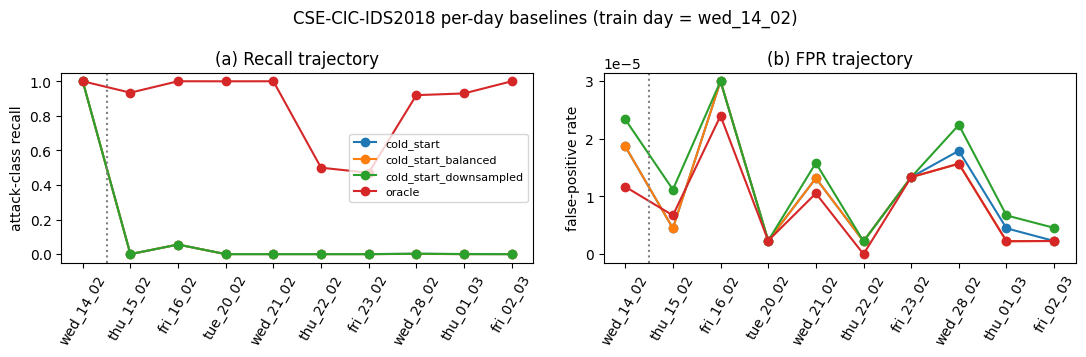

In [7]:
import matplotlib.pyplot as plt
piv_r = base.pivot(index='day', columns='model', values='recall').loc[CSE2018_DAY_ORDER]
piv_f = base.pivot(index='day', columns='model', values='fpr').loc[CSE2018_DAY_ORDER]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for mname in piv_r.columns:
    axes[0].plot(piv_r.index, piv_r[mname], marker='o', label=mname)
    axes[1].plot(piv_f.index, piv_f[mname], marker='o', label=mname)
axes[0].set_ylabel('attack-class recall'); axes[0].set_title('(a) Recall trajectory')
axes[1].set_ylabel('false-positive rate'); axes[1].set_title('(b) FPR trajectory')
for ax in axes:
    ax.tick_params(axis='x', rotation=60); ax.axvline(0.5, ls=':', c='grey')
axes[0].legend(fontsize=8)
fig.suptitle('CSE-CIC-IDS2018 per-day baselines (train day = wed_14_02)')
fig.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(ROOT / 'reports' / 'figures' / f'24_cse2018_trajectory.{ext}', dpi=200)
plt.show()

## 7. G-DRIFT gate (pre-registered, A1.3)

- Reference: frozen recall on **BruteForce** flows in wed_14_02's eval split.
- Per novel-family day: drop = reference − frozen recall on novel-family
  flows that day (days with zero novel-family eval flows are skipped).
- Decisive days: novel-family days excluding Infiltration (A1.3) and any
  family flagged underpowered by the census (Section 2).
- **Gate passes iff** drop ≥ 0.30 on ≥ half of decisive days AND both
  imbalance controls move mean novel-day recall by < 0.01.

In [8]:
ref = famr.query("day == @TRAIN_DAY and model == 'cold_start' and family == 'BruteForce'")
assert len(ref) == 1, 'no BruteForce reference on the training day?'
ref_recall = float(ref['recall'].iloc[0])

novel = famr[(famr.family != 'BruteForce') & (famr.model == 'cold_start')].copy()
novel['drop'] = ref_recall - novel['recall']
novel['decisive'] = ~novel['family'].isin(UNDERPOWERED | {'Infiltration'})
display(novel[['day', 'family', 'n_flows', 'recall', 'drop', 'decisive']]
        .sort_values(['day', 'family']))

decisive = novel[novel.decisive]
frac_big_drop = float((decisive['drop'] >= DRIFT_DROP).mean()) if len(decisive) else np.nan

novel_days = [d for d in CSE2018_DAY_ORDER if d != TRAIN_DAY]
mean_novel = lambda mname: base.query('model == @mname and day in @novel_days')['recall'].mean()
bal_delta = abs(mean_novel('cold_start_balanced') - mean_novel('cold_start'))
ds_delta = abs(mean_novel('cold_start_downsampled') - mean_novel('cold_start'))

gate = {'reference_bruteforce_recall_trainday': round(ref_recall, 3),
        'n_decisive_family_days': int(len(decisive)),
        'frac_decisive_with_drop_ge_0.30': round(frac_big_drop, 3),
        'imbalance_delta_balanced': round(float(bal_delta), 4),
        'imbalance_delta_downsampled': round(float(ds_delta), 4),
        'underpowered_families': sorted(UNDERPOWERED),
        'G_DRIFT_pass': bool(frac_big_drop >= 0.5 and
                             bal_delta < IMBALANCE_EPS and
                             ds_delta < IMBALANCE_EPS)}
with open(ROOT / 'data' / 'processed' / 'phase6_24_cse2018_baseline.json', 'w') as f:
    json.dump({'gate': gate,
               'oracle_mean_novel_recall': round(float(mean_novel('oracle')), 3),
               'frozen_mean_novel_recall': round(float(mean_novel('cold_start')), 3)},
              f, indent=2)
print(json.dumps(gate, indent=2))
verdict = ('G-DRIFT PASS — drift premise holds; proceed to notebook 25.'
           if gate['G_DRIFT_pass'] else
           'G-DRIFT FAIL — 2018 is a mild-regime dataset under this protocol; '
           'benchmark still runs (A1.3) but is reported as mild-regime.')
print('\n' + '='*72 + '\n' + verdict + '\n' + '='*72)

,day,family,n_flows,recall,drop,decisive
40,fri_02_03,Bot,10209,0.000000,1.000000,True
9,fri_16_02,DoS,109802,0.000027,0.999973,True
28,fri_23_02,Web,17,0.000000,1.000000,False
36,thu_01_03,Infiltration,2737,0.000000,1.000000,False
4,thu_15_02,DoS,3130,0.000000,1.000000,True
24,thu_22_02,Web,16,0.000000,1.000000,False
16,tue_20_02,DDoS,21569,0.000000,1.000000,True
20,wed_21_02,DDoS,70073,0.000000,1.000000,True
32,wed_28_02,Infiltration,3414,0.002050,0.997950,False


{
  "reference_bruteforce_recall_trainday": 1.0,
  "n_decisive_family_days": 5,
  "frac_decisive_with_drop_ge_0.30": 1.0,
  "imbalance_delta_balanced": 0.0001,
  "imbalance_delta_downsampled": 0.0001,
  "underpowered_families": [
    "Web"
  ],
  "G_DRIFT_pass": true
}

G-DRIFT PASS — drift premise holds; proceed to notebook 25.


## 8. Log finding + next step

Either verdict routes to notebook 25 (the benchmark) — a FAIL only changes how
the dataset is *reported* (mild regime), per A1.3. Fill and uncomment:

In [9]:
# from src.utils.documentation import log_finding
# log_finding(
#     title='CSE-CIC-IDS2018 baseline & G-DRIFT: <PASS/FAIL>',
#     context='08_phase6_cse2018/24_cse2018_baseline',
#     what_we_did='Family census (A1.2) frozen; cold-start/balanced/downsampled/'
#                 'oracle RFs trained on fixed 70/30 splits; per-day per-family '
#                 'recall; pre-registered G-DRIFT gate evaluated.',
#     what_we_found='<ref recall, frac decisive drops, imbalance deltas, '
#                   'underpowered families, oracle vs frozen mean novel recall>',
#     why_it_matters='Establishes (or scopes) the drift premise on the third '
#                    'dataset before the localization benchmark (notebook 25).',
# )